In [1]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install feature_engine

Note: you may need to restart the kernel to use updated packages.


In [7]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from xgboost import XGBClassifier
from sklearn.utils import resample
import xgboost as xg
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from imblearn.over_sampling import SMOTE
plt.style.use('ggplot')
pd.set_option('display.max.columns',500)

Explonatory Data Analysis: missing values, wrong data type checks , remove duplicates , correct invalid data set.

In [8]:
#data understanding
data = pd.read_csv("/kaggle/input/datasets/oluwanifemiabimbola/frauddetectiondataset/fraudTrain.csv")
data.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [9]:
#random 10 rows of the data to avoid bias
data.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
227832,227832,2019-04-25 11:06:05,2297447006766555,"fraud_Eichmann, Bogan and Rodriguez",gas_transport,74.59,Laura,Walker,F,611 Michael Rue,Cisco,IL,61830,39.9972,-88.6962,478,Landscape architect,1960-01-13,6bd8127122183d3a285096497fad6469,1335351965,39.317492,-88.206201,0
30127,30127,2019-01-18 21:45:38,2254917871818484,fraud_Watsica LLC,personal_care,64.02,Margaret,Gibson,F,382 Williams Stream Suite 197,Scotland,MD,20687,38.0828,-76.3477,313,Insurance underwriter,1976-03-26,b4fcb1953fcd23008c7c7c2cd957b905,1326923138,38.211512,-76.777951,0
278014,278014,2019-05-17 21:14:05,30026790933302,fraud_Padberg-Rogahn,entertainment,66.88,John,Peters,M,555 Michael Burgs,Mayersville,MS,39113,32.9013,-91.0286,595,Technical brewer,1979-09-03,152d515f9ed9ace4accc6d4d45f48178,1337289245,32.339904,-91.211114,0
601439,601439,2019-09-12 19:38:46,6011104316292105,fraud_Fritsch and Sons,health_fitness,30.96,Valerie,Davis,F,3861 Anderson Ramp Apt. 536,Drakes Branch,VA,23937,36.9688,-78.5615,1970,Energy engineer,1985-09-02,f17d6f402c60ce0a9d42b7eb17e5af1d,1347478726,37.106972,-78.401198,0
435270,435270,2019-07-13 22:09:20,343668971234893,fraud_Collier LLC,home,28.90,Sally,Moore,F,835 Reese Views Suite 884,Hopkins,SC,29061,33.9349,-80.8449,13717,Chiropodist,1949-11-16,fc7e98499d27bf3ef137bfd48338a20c,1342217360,34.412131,-80.365973,0
772838,772838,2019-11-26 21:00:35,4789911625179723,fraud_Kilback and Sons,entertainment,53.60,Dorothy,Zuniga,F,77321 Ford Via,Moriches,NY,11955,40.8095,-72.8229,3285,"Research officer, trade union",1988-04-27,42b3e7ee3afbdb7293203cc0551cf784,1353963635,41.444956,-73.260456,0
1170787,1170787,2020-05-03 23:56:12,6511349151405438,fraud_Ziemann-Waters,health_fitness,1.14,Robert,Nguyen,M,74835 Garner Point,Ruth,NV,89319,39.3426,-114.8859,450,Interpreter,1946-08-24,8c58ae3289acfc4197991c53c2273a72,1367625372,38.710684,-114.886028,0
594059,594059,2019-09-09 01:16:22,4279161831637,fraud_Kutch LLC,gas_transport,59.49,Lisa,Hendrix,F,35737 Kirby Fall Suite 409,Vanderbilt,PA,15486,40.0246,-79.6955,2303,Physiotherapist,1987-08-16,2ef93f3b7da0a705f848c4ec669c6d11,1347153382,40.743204,-79.726563,0
336437,336437,2019-06-08 20:30:07,4629451965224809,"fraud_Terry, Johns and Bins",misc_pos,7.57,Karen,Warren,F,4900 Curtis Gardens Suite 952,Hahira,GA,31632,30.9416,-83.3574,10295,"Teacher, special educational needs",1997-12-26,f1003aaa01d6bb0b1c0a0a6492e2e42d,1339187407,31.665347,-83.725153,0
462990,462990,2019-07-23 02:29:04,30044330818990,fraud_Jaskolski-Vandervort,misc_net,18.32,Allison,Ayala,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,26.4722,-81.8122,224256,Paramedic,1985-08-29,80b8c0e2e3f687c318962a7b18b44b05,1343010544,26.190987,-81.895334,0


In [10]:
#checking the missing values and duplicate to avoid high bias in the model
missing_value = data.isna().sum()
duplicate_value = data.duplicated().sum()
print(f'Missing values:{missing_value}')
print(f'Duplicate Value:{duplicate_value}')

Missing values:Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
Duplicate Value:0


In [11]:
#checking the columns,shape rows and column types and describe
data.shape

(1296675, 23)

In [12]:
#the data columns
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [13]:
#make sure the features are in the right format
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [14]:
#more information on the data set
data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


Feature engineering focusing on renaming , removing and creating new features
removing the cc_num as it has scale with large standard deviation as it is on different scale , same with the ID.
feature scaling for the zip, amt and city pop because of high scale value.
create distance features with lat and long,as it reduce dimentionality for simplicity sake for the model

In [15]:
#rename column
data = data.rename(columns={'Unnamed: 0':'ID'})

In [16]:
#confirm the column
data.columns

Index(['ID', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [17]:
#calculating the euclidean distance from a refrence point
ref_lat = data['lat'].mean()
ref_long = data['long'].mean()

data['distance_from_center'] = np.sqrt((data['lat'] - ref_lat) ** 2 + (data['long'] - ref_long)**2)

In [18]:
#drop the exsting lat and long column, drop last and first name
data = data.drop(['last','first'],axis=1)

In [19]:
#randoming checking the datset
data.sample(4)

,ID,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_from_center
488080,488080,2019-08-01 17:08:59,3531606252458308,"fraud_Eichmann, Hayes and Treutel",travel,9.29,M,7911 Campbell Crossing Apt. 725,Stoneham,MA,2180,42.4828,-71.0978,21437,Artist,1964-06-25,f18add511473cef1250e157ff853553c,1343840939,42.347733,-71.394626,0,19.531137
547067,547067,2019-08-22 12:45:25,30263540414123,fraud_Swift PLC,kids_pets,31.10,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,bec7af8b6950250b57030c31b64476fc,1345639525,38.044079,-111.676298,0,22.266473
390830,390830,2019-06-28 06:32:09,30026790933302,fraud_Cormier LLC,shopping_net,87.14,M,555 Michael Burgs,Mayersville,MS,39113,32.9013,-91.0286,595,Technical brewer,1979-09-03,4d39f0af137137e590bee3b311f1ca94,1340865129,33.682562,-90.347858,0,5.693132
794641,794641,2019-12-02 18:56:57,3529597930342630,fraud_Little Ltd,kids_pets,138.13,F,81708 Christopher Plaza,Jordanville,NY,13361,42.8948,-74.8209,824,Travel agency manager,1985-09-01,ea8df2a9728f0e597c66d893c0cbcaf7,1354474617,41.931697,-75.206410,0,16.009761


In [20]:
#checking the data is balanace or not and it is imbalance , we have less of fraud data
data.groupby('is_fraud')['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [21]:
#convert date to year,month,day and into hour, minute and second.
data['transac_date'] = pd.to_datetime(data['trans_date_trans_time'])
data['year'] = data['transac_date'].dt.year
data['month'] = data['transac_date'].dt.month
data['quarter'] = data['transac_date'].dt.quarter
data['dayoftheweek'] = data['transac_date'].dt.day_of_week
data['time'] = data['transac_date'].dt.time
data['hour']= data['transac_date'].dt.hour
data['minute'] = data['transac_date'].dt.minute
data['second'] = data['transac_date'].dt.second

In [22]:
#computing the time since last transaction per customer in seconds
data = data.sort_values('transac_date')
data['time_since_last_transaction'] = (data.groupby('ID')['transac_date']
                                       .diff()
                                       .dt.total_seconds()
                                       .fillna(0)
)

In [23]:
#flagging the rapid transaction potential fraud :
#transaction under 60 seconds apart from the customer are a strong fraud indicator
data['is_rapid_txn'] = (data['time_since_last_transaction']< 60).astype(int)

In [24]:
#extracting the birth year to calculate their age to the time of fraud
data['dob'] = pd.to_datetime(data['dob'])
data['birth_year'] = data['dob'].dt.year
#calculatetheclientage
data['age'] = data['year'] - data['birth_year']

In [25]:
#group the time of the day into broader category like morning ,afternoon,evening,night
def categorize_time_of_day(hour):
    if hour >= 6 and hour <=11:
      return 'Morning'
    elif hour >=12 and hour <= 17:
      return 'Afternoon'
    elif hour >=18 and hour <=23:
      return 'evening'
    else:
      return 'Night'



data['season_of_day'] =data['hour'].apply(categorize_time_of_day)

In [26]:
#group the day of the week into week day and weekends
def group_week_day(dayofw):
  wk_day = [1,2,3,4,5]
  week_end = [0,6]
  if dayofw in wk_day:
    return 'weekday'
  else:
    return 'weekend'


data['time_of_the_week'] = data['dayoftheweek'].apply(group_week_day)


In [27]:
#drop the transac transac column since it has been converted
data = data.drop(['trans_date_trans_time','transac_date'],axis=1)

In [28]:
#drop the date of birth
data = data.drop(['dob','time'],axis=1)

Explonatory Data Analysis(Univariate and Muiltivariate): Understanding the features and the relationship between the features.

Text(0, 0.5, 'Sum of the Age')

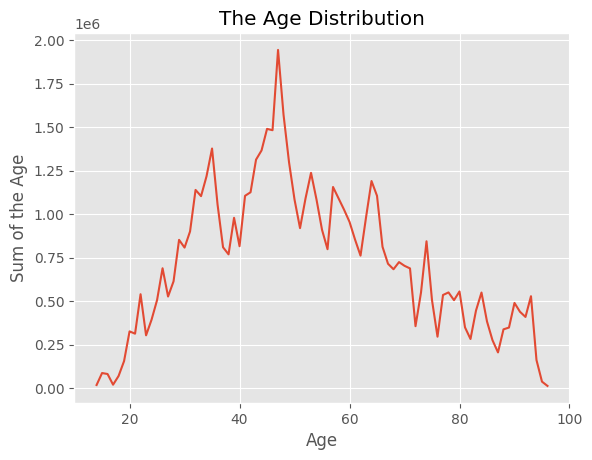

In [29]:
#age group distribution
age_grp = data.groupby('age')['age'].sum()
age_grp.plot(kind='line')
plt.title('The Age Distribution')
plt.xlabel('Age')
plt.ylabel('Sum of the Age')
#plt.xticks(rotation=90)


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.]),
 [Text(-1.0, 0, '(evening, 1)'),
  Text(0.0, 0, '(Afternoon, 0)'),
  Text(1.0, 0, '(Afternoon, 1)'),
  Text(2.0, 0, '(Morning, 0)'),
  Text(3.0, 0, '(Morning, 1)'),
  Text(4.0, 0, '(Night, 0)'),
  Text(5.0, 0, '(Night, 1)'),
  Text(6.0, 0, '(evening, 0)'),
  Text(7.0, 0, '(evening, 1)'),
  Text(8.0, 0, '')])

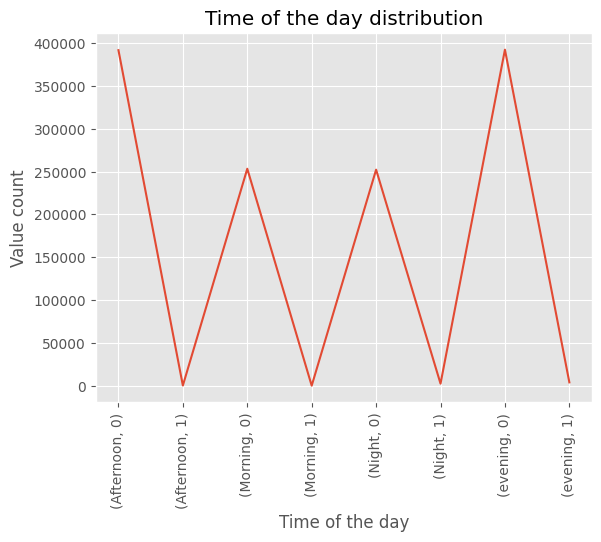

In [30]:
#time of day distribution
time_of_day = data.groupby('season_of_day')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5]),
 [Text(-0.5, 0, ''),
  Text(0.0, 0, '(weekday, 0)'),
  Text(0.5, 0, ''),
  Text(1.0, 0, '(weekday, 1)'),
  Text(1.5, 0, ''),
  Text(2.0, 0, '(weekend, 0)'),
  Text(2.5, 0, ''),
  Text(3.0, 0, '(weekend, 1)'),
  Text(3.5, 0, '')])

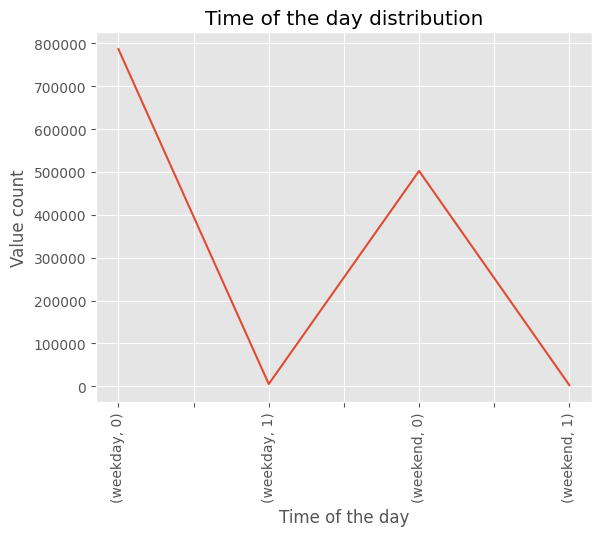

In [31]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

Text(0, 0.5, 'value count')

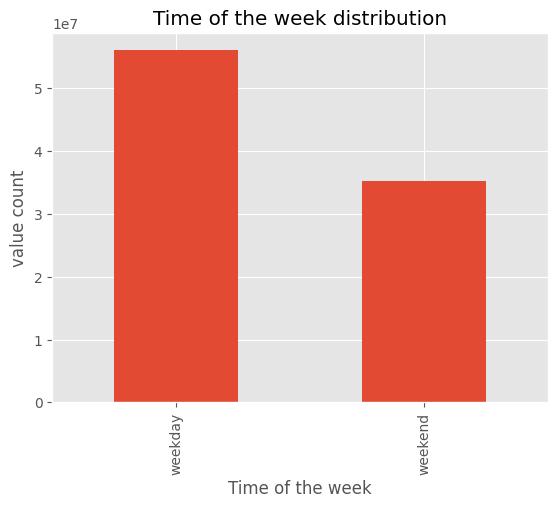

In [32]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['amt'].sum()
time_of_day.plot(kind='bar')
plt.title('Time of the week distribution')
plt.xlabel('Time of the week')
plt.ylabel('value count')
#plt.xticks(rotation=90)

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(-2.0, 0, 'shopping_pos'),
  Text(0.0, 0, 'entertainment'),
  Text(2.0, 0, 'gas_transport'),
  Text(4.0, 0, 'grocery_pos'),
  Text(6.0, 0, 'home'),
  Text(8.0, 0, 'misc_net'),
  Text(10.0, 0, 'personal_care'),
  Text(12.0, 0, 'shopping_pos'),
  Text(14.0, 0, '')])

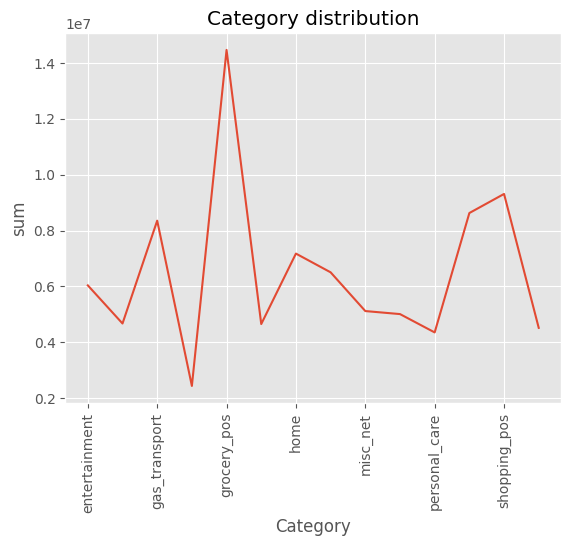

In [33]:
#category distribution
time_of_day = data.groupby('category')['amt'].sum()
time_of_day.plot(kind='line')
plt.title('Category distribution')
plt.xlabel('Category')
plt.ylabel('sum')
plt.xticks(rotation=90)

In [34]:
#merchant distribution in the dataset
data.groupby('merchant')['is_fraud'].value_counts().tail(10)

merchant                          is_fraud
fraud_Zemlak Group                0           1280
                                  1             17
fraud_Zemlak, Tillman and Cremin  0           1802
                                  1              2
fraud_Ziemann-Waters              0           1689
                                  1              6
fraud_Zieme, Bode and Dooley      0           2552
                                  1              8
fraud_Zulauf LLC                  0           1781
                                  1              2
Name: count, dtype: int64

In [35]:
#Category distribution in the dataset
data.groupby('category')['is_fraud'].value_counts()

category        is_fraud
entertainment   0            93781
                1              233
food_dining     0            91310
                1              151
gas_transport   0           131041
                1              618
grocery_net     0            45318
                1              134
grocery_pos     0           121895
                1             1743
health_fitness  0            85746
                1              133
home            0           122917
                1              198
kids_pets       0           112796
                1              239
misc_net        0            62372
                1              915
misc_pos        0            79405
                1              250
personal_care   0            90538
                1              220
shopping_net    0            95830
                1             1713
shopping_pos    0           115829
                1              843
travel          0            40391
                1             

In [36]:
# the distribution of age with fraud
data.groupby('age')['is_fraud'].value_counts().sample(10)

age  is_fraud
26   0           26390
72   1              25
35   0           39198
44   0           30934
93   0            5668
86   1              40
41   1              84
35   1             133
47   0           41178
49   0           26283
Name: count, dtype: int64

In [37]:
#gender distribution
data.groupby('gender')['is_fraud'].value_counts()

gender  is_fraud
F       0           706128
        1             3735
M       0           583041
        1             3771
Name: count, dtype: int64

<Axes: title={'center': 'the difference in the gender distribution'}, xlabel='gender'>

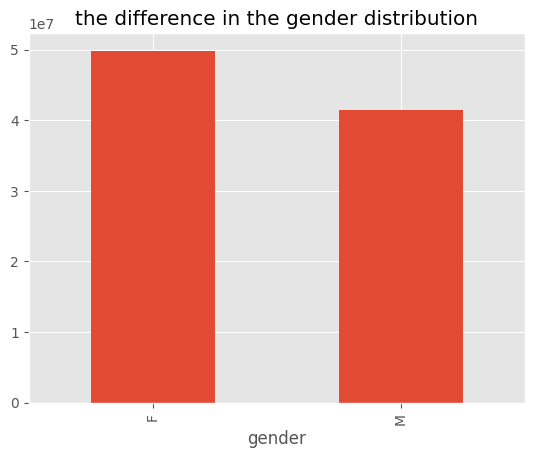

In [38]:
#plotting the distribution of data among the gender
gender_dist = data.groupby('gender')['amt'].sum()
gender_dist.plot(kind='bar',title='the difference in the gender distribution')

<Axes: xlabel='is_fraud'>

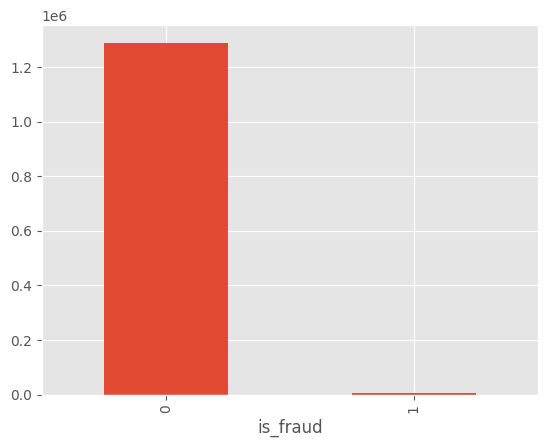

In [39]:
#the fraud dataset distribution
fraud_distribution = data.groupby('is_fraud')['is_fraud'].value_counts()
fraud_distribution.plot(kind='bar')

In [40]:
#correlation for the features relationship
#Extracting the numeric data
numerical_cos = data.select_dtypes(include=[np.number])
numerical_cos.corr()

,ID,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,distance_from_center,year,month,quarter,dayoftheweek,hour,minute,second,time_since_last_transaction,is_rapid_txn,birth_year,age
ID,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767,-0.001126,0.783311,0.181956,0.151242,-0.030910,0.001073,0.000030,0.000174,NaN,NaN,0.003736,0.016644
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,0.053220,0.000466,-0.000281,-0.000465,-0.002481,-0.000801,0.000812,0.000036,NaN,NaN,0.000291,-0.000279
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,0.002640,0.000842,-0.001748,-0.001962,-0.001001,-0.022811,0.000383,0.001405,NaN,NaN,0.009748,-0.009724
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.227925,0.000086,0.000852,0.000500,-0.001353,0.005938,0.000766,0.000127,NaN,NaN,-0.011004,0.011004
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,0.185967,0.001274,-0.001072,-0.001342,0.000498,-0.011508,-0.000243,-0.000221,NaN,NaN,-0.047845,0.047868
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.519266,0.000191,-0.001213,-0.000697,0.001593,-0.002290,-0.000825,0.000325,NaN,NaN,0.030231,-0.030220
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,0.056586,-0.001673,0.000137,-0.000280,0.002439,0.020381,-0.000713,0.000690,NaN,NaN,0.091271,-0.091295
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,-0.001145,0.782582,0.184868,0.153618,-0.029284,0.000756,0.000006,0.000191,NaN,NaN,0.003655,0.016707
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,0.184745,0.001244,-0.001116,-0.001428,0.000263,-0.011378,-0.000217,-0.000281,NaN,NaN,-0.047458,0.047480
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.518812,0.000184,-0.001197,-0.000688,0.001553,-0.002325,-0.000820,0.000310,NaN,NaN,0.030154,-0.030142


In [41]:
#checking the skewness of the numeric data
#ignoring the skew data , since its random forest model
numerical_cos.skew()

ID                            -5.176828e-15
cc_num                         2.851879e+00
amt                            4.227787e+01
zip                            7.968076e-02
lat                           -1.860277e-01
long                          -1.150108e+00
city_pop                       5.593853e+00
unix_time                      3.377950e-03
merch_lat                     -1.819154e-01
merch_long                    -1.146960e+00
is_fraud                       1.302912e+01
distance_from_center           2.245465e+00
year                           9.430622e-01
month                          2.985158e-01
quarter                        2.585613e-01
dayoftheweek                  -7.845304e-02
hour                          -2.828255e-01
minute                        -3.937129e-04
second                        -6.966114e-04
time_since_last_transaction    0.000000e+00
is_rapid_txn                   0.000000e+00
birth_year                    -6.123585e-01
age                            6

In [42]:
numerical_cos.columns

Index(['ID', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'distance_from_center', 'year',
       'month', 'quarter', 'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'birth_year', 'age'],
      dtype='object')

<Axes: ylabel='Frequency'>

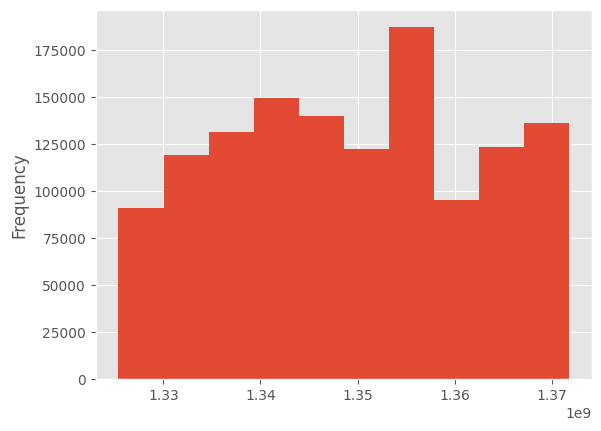

In [43]:
#positive skewed data evaluating via histogram cc_num,amt,zip,city_pop,age, unix, distance_from_center,year,month,quarter 
numerical_cos['unix_time'].plot(kind='hist')

In [44]:
#log transformation on skew data
skewed_data = ['amt','city_pop','distance_from_center']

# Apply natural log
data[skewed_data] = data[skewed_data].apply(np.log1p)

In [45]:
#remove ccnum and id
data = data.drop(columns=['cc_num','ID','birth_year','trans_num'], axis=1)

In [46]:
#the function to calculate the difference in the target value
def percentage_increase(fra,not_frad):
    percentage_difference_fra = round((fra/(fra + not_frad)) * 100, 2)
    percentage_difference_not_frad = round((not_frad/(fra + not_frad)) *100,2)
    return (f'fraud:{percentage_difference_fra}, Not Fraud:{percentage_difference_not_frad}')


fra = data['is_fraud'].value_counts()[1]
not_frad = data['is_fraud'].value_counts()[0]

percentage_increase(fra,not_frad)

'fraud:0.58, Not Fraud:99.42'

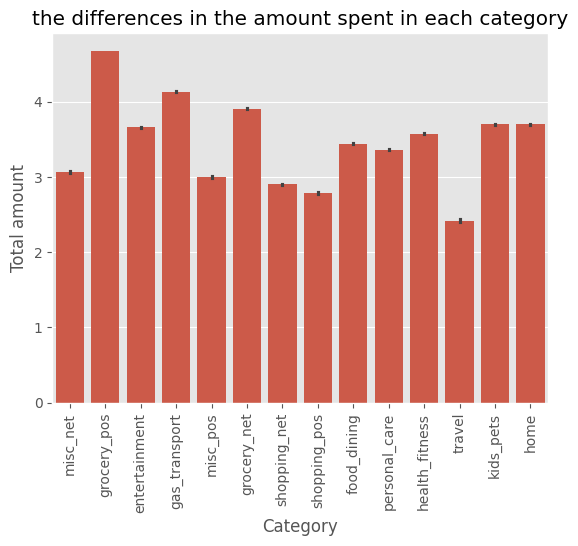

In [47]:
#category amount distribution
sns.barplot(data=data, x='category', y='amt')
plt.title('the differences in the amount spent in each category')
plt.xlabel('Category')
plt.ylabel('Total amount')
plt.xticks(rotation=90)
plt.show()

Splitting of the dataset into Train and Test set

In [48]:
#splitting data into input and output
X = data.drop(['is_fraud'], axis = 1)
y = data['is_fraud']

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

Encoding the categorical data: For the test data we use the transform while the train data we use the fit. It is best to encode the dataset after split to avoid data leakeage.


In [50]:
#Extracting the numeric data
numerical_columns = X_train.select_dtypes(include=[np.number])
numerical_columns.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'month', 'quarter',
       'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age'],
      dtype='object')

In [51]:
#extracting the categorical data
categorical_columns = X_train.select_dtypes(include=['object'])
categorical_columns.columns

Index(['merchant', 'category', 'gender', 'street', 'city', 'state', 'job',
       'season_of_day', 'time_of_the_week'],
      dtype='object')

In [52]:
#for columns like month minute,hour,day of the week, second we need cyclical encoding,
 #but since it is random forest we will leave it' cyclical encoding does not have any significant
 #on tree models. but we keep it for other models
# Hour: 24-hour cycle
X_train['hour_sin'] = np.sin(2 * np.pi * X_train['hour'] / 24)
X_train['hour_cos'] = np.cos(2 * np.pi * X_train['hour'] / 24)

# #x_test
X_test['hour_sin'] = np.sin(2 * np.pi * X_test['hour'] / 24)
X_test['hour_cos'] = np.cos(2 * np.pi * X_test['hour'] / 24)

# Day of week: 7-day cycle
X_train['day_sin'] = np.sin(2 * np.pi * X_train['dayoftheweek'] / 7)
X_train['day_cos'] = np.cos(2 * np.pi * X_train['dayoftheweek'] / 7)

# #X_test
X_test['day_sin'] = np.sin(2 * np.pi * X_test['dayoftheweek'] / 7)
X_test['day_cos'] = np.cos(2 * np.pi * X_test['dayoftheweek'] / 7)


# Month: 12-month cycle
X_train['month_sin'] = np.sin(2 * np.pi * X_train['month'] / 12)
X_train['month_cos'] = np.cos(2 * np.pi * X_train['month'] / 12)

# #X_test
X_test['month_sin'] = np.sin(2 * np.pi * X_test['month'] / 12)
X_test['month_cos'] = np.cos(2 * np.pi * X_test['month'] / 12)

# Drop the original columns after encoding
X_train = X_train.drop(columns=['hour', 'dayoftheweek', 'month'])
X_test = X_test.drop(columns=['hour', 'dayoftheweek', 'month'])

In [53]:
numerical_columns.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'month', 'quarter',
       'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age'],
      dtype='object')

(array([1, 2, 3, 4]),
 [Text(1, 0, 'amt'),
  Text(2, 0, 'lat'),
  Text(3, 0, 'long'),
  Text(4, 0, 'city_pop')])

<Figure size 4000x2400 with 0 Axes>

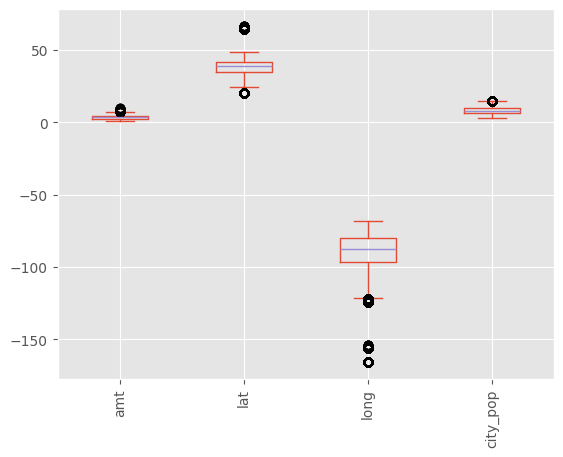

In [54]:
#for outliers
from matplotlib.pyplot import figure

figure(figsize=(50, 30), dpi=80)
sub_numeric =numerical_columns[['amt', 'lat', 'long', 'city_pop']]
sub_numeric_2 =numerical_columns[['dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age']]
sub_numeric.plot(kind='box')
plt.xticks(rotation=90)

In [58]:
#removing outlier

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outlier_summary = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
         ].shape[0]

        outlier_summary[col] = outliers

       # Remove outliers
        df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
        ]
 
    for col, count in outlier_summary.items():
        print(f" {col}: {count} outliers")

        print(f"\nOriginal shape: {df.shape}")
        print(f"Clean shape: {df_clean.shape}")

    return df_clean

# Your numerical columns
numerical_cols = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'quarter', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age']
X_train_clean = remove_outliers_iqr(X_train, numerical_cols)

 amt: 539 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 lat: 3145 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 long: 30187 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 city_pop: 2762 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 unix_time: 0 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 merch_lat: 138 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 merch_long: 7274 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 distance_from_center: 15132 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 year: 0 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 quarter: 0 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 minute: 0 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 second: 0 outliers

Original shape: (868772, 31)
Clean shape: (809223, 31)
 time_since_last_transaction: 0 outliers

Original

In [59]:
# #for columns like zip, merchant,job,transnum,category,street, city, state,frequency encoder:
# #frequency encoder works by replacing values base on the number or percentage of times they appear.
# #convert zip to categorical data
X_train['zip'] = X_train['zip'].astype(str)
X_test['zip'] = X_test['zip'].astype(str)

In [60]:
#part 2 of encoding the features using frequency encoder
#zip, merchant,job,transnum,category,street, city, state
encoder = CountFrequencyEncoder(encoding_method='frequency',
                                variables=['merchant','zip','job',
                                           'category','street','city','state'],
)

encoder.fit(X_train)

CountFrequencyEncoder(encoding_method='frequency',
                      variables=['merchant', 'zip', 'job', 'category', 'street',
                                 'city', 'state'])

In [61]:
#fit the transform on the training and test data
X_train = encoder.transform(X_train)
X_test = encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt gender    street      city     state  \
741541   0.001951  0.095594  4.672735      M  0.000393  0.000393  0.043324   
268287   0.001803  0.095024  2.583998      M  0.001165  0.001165  0.020744   
1175073  0.000691  0.034915  3.884241      F  0.001204  0.001204  0.035663   
1252348  0.001789  0.087136  5.066007      F  0.001662  0.001662  0.064611   
815516   0.001910  0.095594  4.715817      M  0.000821  0.000821  0.009113   

              zip      lat      long  city_pop       job   unix_time  \
741541   0.000393  34.2980 -114.1560  4.844187  0.000393  1352769207   
268287   0.001165  41.2001  -92.1354  6.343880  0.002357  1336865106   
1175073  0.001204  42.3703  -84.2485  7.833600  0.001204  1367753697   
1252348  0.001662  43.2237  -75.1612  7.429521  0.005985  1370450317   
815516   0.000821  45.1939 -112.0568  5.659482  0.000828  1354930058   

         merch_lat  merch_long  distance_from_center  year  quarter  minute  \
741541   33.817199 

In [62]:
X_train.shape

(868772, 31)

In [63]:
#for columns like gender,  'time_of_the_week' binary encoder
#fit into the train set and transform on both train and test set
binary_encoder = ce.BinaryEncoder(cols=['gender','time_of_the_week'],
                                  return_df=True)
#fit the transform on the training and test data
binary_encoder.fit(X_train)
X_train = binary_encoder.transform(X_train)
X_test = binary_encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt  gender_0  gender_1    street      city  \
741541   0.001951  0.095594  4.672735         0         1  0.000393  0.000393   
268287   0.001803  0.095024  2.583998         0         1  0.001165  0.001165   
1175073  0.000691  0.034915  3.884241         1         0  0.001204  0.001204   
1252348  0.001789  0.087136  5.066007         1         0  0.001662  0.001662   
815516   0.001910  0.095594  4.715817         0         1  0.000821  0.000821   

            state       zip      lat      long  city_pop       job  \
741541   0.043324  0.000393  34.2980 -114.1560  4.844187  0.000393   
268287   0.020744  0.001165  41.2001  -92.1354  6.343880  0.002357   
1175073  0.035663  0.001204  42.3703  -84.2485  7.833600  0.001204   
1252348  0.064611  0.001662  43.2237  -75.1612  7.429521  0.005985   
815516   0.009113  0.000821  45.1939 -112.0568  5.659482  0.000828   

          unix_time  merch_lat  merch_long  distance_from_center  year  \
741541   135276920

In [64]:
#checking the cardinality of the variable
X_train[['season_of_day']].nunique()

season_of_day    4
dtype: int64

In [65]:
# for the 'season_of_day', one hot encoding
one_hot_encoder = OneHotEncoder(
    variables=['season_of_day'],
    drop_last=True,
    )

one_hot_encoder.fit(X_train)

OneHotEncoder(drop_last=True, variables=['season_of_day'])

In [68]:
X_train = one_hot_encoder.transform(X_train)
X_test = one_hot_encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt  gender_0  gender_1    street      city  \
741541   0.001951  0.095594  4.672735         0         1  0.000393  0.000393   
268287   0.001803  0.095024  2.583998         0         1  0.001165  0.001165   
1175073  0.000691  0.034915  3.884241         1         0  0.001204  0.001204   
1252348  0.001789  0.087136  5.066007         1         0  0.001662  0.001662   
815516   0.001910  0.095594  4.715817         0         1  0.000821  0.000821   

            state       zip      lat      long  city_pop       job  \
741541   0.043324  0.000393  34.2980 -114.1560  4.844187  0.000393   
268287   0.020744  0.001165  41.2001  -92.1354  6.343880  0.002357   
1175073  0.035663  0.001204  42.3703  -84.2485  7.833600  0.001204   
1252348  0.064611  0.001662  43.2237  -75.1612  7.429521  0.005985   
815516   0.009113  0.000821  45.1939 -112.0568  5.659482  0.000828   

          unix_time  merch_lat  merch_long  distance_from_center  year  \
741541   135276920

In [ ]:
# #ignoring the skewness and outlier for random forest
# #Imbalance dataset
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
#         color=['skyblue','salmon'])
# plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
# plt.ylabel("Count")
# plt.title("Class Distribution AFTER SMOTE")
# plt.show()

In [66]:
#calculate the scale_pos_weight
ratio = (y_train == 0).sum()/(y_train==1).sum()
print(ratio)

172.40758483033932


In [ ]:
# #hyperparameter tuning using the gridsearch
# grid= { 'scale_pos_weight' : [1],
#              'learning_rate' : [0.01,0.05,0.1,0.2],
#              'n_estimators' : [100,300,500],
#              'max_depth' : [3,4,5,6],
#              'subsample':[0.5,0.7]
#              }

In [ ]:
# # Create the RandomizedSearchCV object
# estimators = XGBClassifier()
# gs=RandomizedSearchCV(estimator= estimators,
#                       param_distributions=grid, 
#                       n_iter = 20,
#                       cv=5,
#                       n_jobs = -1,
#                       scoring = 'roc_auc',
#                       random_state = 42)
# # now fit the dataset to the GridSearchCV object. 
# #sampling of the data
# X_sample, y_sample = resample(X_train_sm,y_train_sm,
#                              n_samples = 50000,random_state = 42)
# gs= gs.fit(X_sample, y_sample)

In [ ]:
# # 1. Fit the RandomizedSearchCV object
# best_params = gs.best_params_
# best_score = gs.best_score_
# print(best_params)
# print(best_score)

In [69]:
#fitting xgboost
from xgboost  import XGBClassifier
model = XGBClassifier(objective="binary:logistic",
                      subsample = 0.7,
                      scale_pos_weight = 172.4,
                      n_estimators = 300,
                      max_depth = 6,
                      learning_rate = 0.1,
                      random_state=42)
model.fit(X_train,y_train)

y_pred_sm = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

Accuracy: 99.61 %

ROC-AUC: 0.9751601617610779
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    425407
           1       0.61      0.95      0.74      2496

    accuracy                           1.00    427903
   macro avg       0.80      0.98      0.87    427903
weighted avg       1.00      1.00      1.00    427903



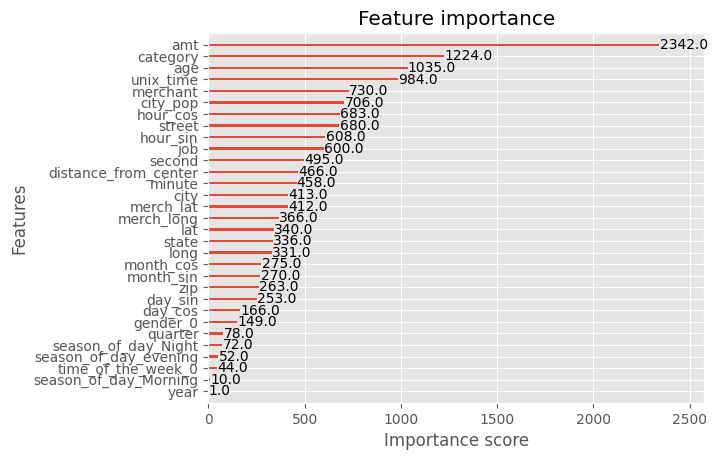

In [70]:
from xgboost import plot_importance

# plot feature importance
plot_importance(model)
plt.show()

In [71]:
# Compare train vs test performance for overfitting 
y_train_pred = model.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

Train accuracy: 0.9970717288310397
Test accuracy: 0.9961463228815877


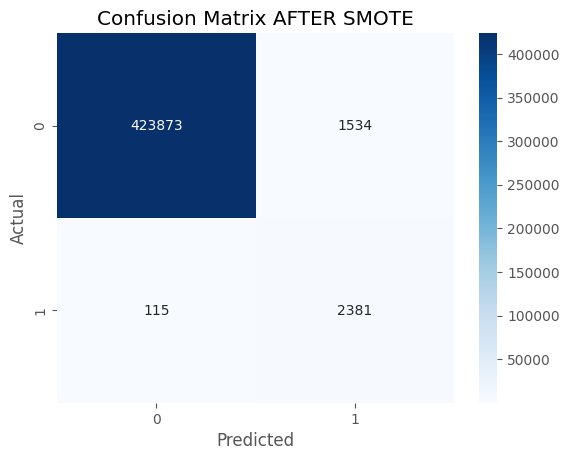

In [72]:
#confusion matrics graph
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# #improving the model precision by using shap to understand the feature ,
# #hyperparameter tuning ,more feature engineering,threshold tuning,resampling
# #using shap
# # Fits the explainer
# explainer = shap.TreeExplainer(model)
# # Calculates the SHAP values - It takes some time
# shap_values = explainer.shap_values(X_test)

In [ ]:
# #plotiing the shap values
# shap.plots.bar(shap_values)


In [ ]:
# shap.plots.bar(shap_values[0])

In [ ]:
# shap.plots.beeswarm(shap_values)